In [1]:
import glob
import math
import pickle
import datetime
import os, shutil
import pickle
import re
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import gudhi as gd


from pathlib import Path
from scipy.stats import pearsonr
from numpy.linalg import eig
from numpy.linalg import eigh
from datetime import datetime, timedelta
from numpy import nan
from itertools import groupby
from itertools import repeat
from scipy import linalg
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from ripser import ripser
from persim import plot_diagrams

plt.rcParams['text.usetex'] = False

In [78]:
import numpy as np
import pandas as pd
from numba import njit, prange


@njit
def compute_g_mean(X, alpha):
    m, n = X.shape

    # manual row mean
    mean_vec = np.zeros(m)

    for i in range(m):
        s = 0.0
        for j in range(n):
            s += X[i, j]
        mean_vec[i] = s / n

    # beta exponent
    beta = alpha / (alpha - 1)

    # beta norm of mean
    beta_norm = 0.0
    for i in range(m):
        beta_norm += np.abs(mean_vec[i]) ** beta

    beta_norm = beta_norm ** (1.0 / beta)

    # g = mean / (1 + ||mean||_beta)
    g = mean_vec / (1.0 + beta_norm)

    return g


@njit
def finsler_metric_jit(p, q, f, g, alpha):
    diff = np.abs(q - p)
    
#     term1 = np.sum(
#         f * diff**alpha
#     ) ** (1.0 / alpha)  

#     term2 = np.sum(
#         g * (f**(1.0 / alpha)) * (q - p)
#     )


    term1 = np.sum(
         diff**alpha
    ) ** (1.0 / alpha)

    term2 = np.sum(
        g * (q - p)
    )

    return term1 + term2


@njit(parallel=True)
def finsler_matrix_numba(X, alpha):
    m, n = X.shape

    # f_i = p_i²
    f_all = X**2

    # global g vector from dataframe mean
    g = compute_g_mean(X, alpha)

    # allocate matrix
    M = np.zeros((n, n))

    for i in prange(n):
        p = X[:, i]
        f = f_all[:, i]

        for j in range(n):
            q = X[:, j]

            M[i, j] = finsler_metric_jit(
                p, q, f, g, alpha
            )

    return M


def compute_finsler_matrix_numba(df, alpha):
    X = df.to_numpy().astype(np.float64)

    ids = df.columns

    M = finsler_matrix_numba(X, alpha)
    M = np.triu(M) + np.triu(M, k=1).T

    return pd.DataFrame(
        M,
        index=ids,
        columns=ids
    )

# READING & ORGANISING DATA

In [3]:
all_files = glob.glob('stocks/*.csv')

In [4]:
li = []
for filename in all_files:
    df = pd.read_csv(filename, index_col = None, header = 0, on_bad_lines='skip')
    li.append(df)

In [5]:
for df in li:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    

In [6]:
df_list_horario = []
for df in li:
    mask_time = df['timestamp'].dt.strftime('%H:%M').between('09:30', '16:00')
    df_filtered = df.loc[mask_time].sort_values('timestamp').reset_index(drop=True)
    df_list_horario.append(df_filtered)
    

In [129]:
df_list_horario[0]

,timestamp,open,high,low,close,volume
0,2025-08-21 09:30:00,145.67,146.0000,144.910,146.000,14565
1,2025-08-21 09:33:00,145.61,145.6100,145.340,145.580,2723
2,2025-08-21 09:34:00,145.38,145.4200,145.235,145.235,2040
3,2025-08-21 09:35:00,144.96,144.9600,144.730,144.730,1422
4,2025-08-21 09:36:00,145.11,145.1800,144.700,144.720,1742
...,...,...,...,...,...,...
7857,2025-09-19 15:56:00,144.92,144.9500,144.840,144.895,10969
7858,2025-09-19 15:57:00,144.85,144.9100,144.660,144.865,36319
7859,2025-09-19 15:58:00,144.89,145.0100,144.760,144.950,80722
7860,2025-09-19 15:59:00,144.91,145.0500,144.730,144.760,44821


In [7]:
all_days = pd.date_range(start="2025-08-21", end="2025-09-19", freq="B")  # B = business days

# Create a list to store all timestamps
full_timestamps = []

for day in all_days:
    # Timestamps from 09:30 to 16:00
    daily_index = pd.date_range(
        start=day + pd.Timedelta(hours=9, minutes=30),
        end=day + pd.Timedelta(hours=16),
        freq="T"  # 1-minute bars
    )
    full_timestamps.extend(daily_index)  # add to the list

# Convert to a DatetimeIndex
full_idx = pd.DatetimeIndex(full_timestamps)

In [8]:
filled_list = []

for df in df_list_horario:
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()

    # Reindex to include all expected timestamps
    df = df.reindex(full_idx)

    # Forward-fill OHLC
    df[['open','high','low','close']] = df[['open','high','low','close']].ffill()

    # Fill remaining NaNs (at the start) with first available close price
    first_price = df['close'].dropna().iloc[0]
    df[['open','high','low','close']] = df[['open','high','low','close']].fillna(first_price)

    # Restore timestamp as a column
    df = df.reset_index().rename(columns={'index':'timestamp'})
    filled_list.append(df)


In [9]:
timestamp_df = filled_list[0][['timestamp']].copy()

# all close columns at once
close_cols = [
    df['close'].rename(f'close_{i}')
    for i, df in enumerate(filled_list)
]

# concatenate once
merged_df = pd.concat([timestamp_df] + close_cols, axis=1)

In [10]:
merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'])

per_day_list = [
    group.reset_index(drop=True)
    for _, group in merged_df.groupby(
        merged_df['timestamp'].dt.date
    )
]

In [11]:
close_cols = [col for col in merged_df.columns if col.startswith('close_')]

log_returns_df = merged_df.copy()

log_returns_df[close_cols] = np.log(
    merged_df[close_cols] / merged_df[close_cols].shift(1)
)

log_returns_df = log_returns_df.dropna().reset_index(drop=True)
log_returns_df.drop(columns=['timestamp'], inplace=True)

In [12]:
log_returns_df

,close_0,close_1,close_2,close_3,close_4,close_5,close_6,close_7,close_8,close_9,...,close_272,close_273,close_274,close_275,close_276,close_277,close_278,close_279,close_280,close_281
0,0.000000,0.000000,0.006315,0.003070,0.000000,-0.002483,0.000480,-0.004159,-0.000364,-0.004965,...,-0.000301,0.000770,0.000000,0.001955,-0.000188,-0.001759,0.001293,0.000247,-0.003435,-0.000070
1,0.000000,0.000926,0.004417,0.001516,0.000875,0.002876,0.004041,0.004702,0.000000,0.004677,...,0.002238,0.002175,-0.000880,0.001951,0.000063,0.001111,0.000775,0.001235,0.000538,0.002027
2,-0.002881,0.000285,-0.004038,0.002175,-0.003102,0.000000,0.000000,0.000000,0.001434,0.000000,...,0.000919,0.001881,0.000602,-0.000417,-0.000126,-0.002873,-0.000775,-0.000741,0.000000,0.001956
3,-0.002373,0.000214,-0.001517,-0.003501,-0.001722,0.001661,-0.001426,0.000280,0.000000,-0.000262,...,-0.001051,0.000650,-0.000417,-0.000420,0.000000,0.001206,-0.001293,-0.002226,-0.004276,-0.001117
4,-0.003483,-0.000071,-0.000224,0.000853,-0.003523,0.000000,-0.000949,-0.000082,0.000000,-0.000866,...,-0.002256,0.000000,0.000185,-0.001115,0.000000,-0.000185,0.000000,-0.000991,0.001199,-0.002798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8596,-0.000207,0.000224,-0.000490,-0.000028,-0.000430,-0.001354,0.000888,0.000207,-0.001529,-0.000801,...,-0.000634,0.000227,-0.000832,-0.000758,-0.000839,-0.001204,-0.003557,-0.000851,-0.000084,0.000000
8597,-0.000207,0.000149,0.000816,0.001348,0.000000,-0.000263,0.000443,-0.000017,0.000373,0.000481,...,0.000475,0.000040,0.000324,0.000455,-0.000065,0.000185,-0.000730,-0.000213,0.000752,-0.000390
8598,0.000587,0.000373,0.000978,0.001066,-0.000860,0.000677,-0.001331,0.000655,-0.000597,0.000160,...,0.000792,-0.000669,-0.000139,0.000000,-0.000388,0.000648,0.000215,-0.000639,-0.000418,0.000260
8599,-0.001312,-0.000448,-0.000896,-0.001346,0.000000,-0.000150,-0.000666,0.000654,-0.001344,-0.000854,...,-0.000158,-0.000830,-0.001481,-0.001061,0.000194,0.000278,0.000429,-0.000426,-0.002007,-0.001302


In [13]:
window_size = 60

subdfs_log_returns_df = [
    log_returns_df.iloc[i:i + window_size].copy()
    for i in range(len(log_returns_df) - window_size + 1)
]

In [14]:
subdfs_log_returns_df = [
    df for df in subdfs_log_returns_df
    if hasattr(df, 'eq') and not (df == 0).all().all()
]

In [130]:
import numpy as np

window_size = 50  # same used in TDA

market_volatility = []

for i in range(len(log_returns_df) - window_size + 1):

    window = log_returns_df.iloc[i:i+window_size]

    # volatility of each asset
    asset_vol = window.std()

    # market volatility
    mean_vol = asset_vol.mean()

    market_volatility.append(mean_vol)

market_volatility = np.array(market_volatility)

# MATRICES COMPUTATION


In [16]:
dist_matr_euclidean = []
for n, df in enumerate(subdfs_log_returns_df):
    df_T = df.T
    X = df_T.T.values
    
    dist_matrix = np.sqrt(((X[:, None, :] - X[None, :, :])**2).sum(axis=2))

    dist_matrix = pd.DataFrame(dist_matrix, index=df_T.columns, columns=df_T.columns)
    dist_matr_euclidean.append(dist_matrix)


In [79]:
finsler_matrices = []

for df in subdfs_log_returns_df:
    df_T = df.T
    M = compute_finsler_matrix_numba(df_T, 2)
    finsler_matrices.append(M)

# PERSISTENCE COMPUTATION


In [18]:
H1_euclidean = []
percentages_max_H1_euclidean = []
for n, df in enumerate(dist_matr_euclidean):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_euclidean.append(pct)
    H1_euclidean.append(len(H1))

In [1]:
H2_euclidean = []
percentages_max_H2_euclidean = []

for n, df in enumerate(dist_matr_euclidean):
    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True,
        maxdim=2
    )['dgms']

    H2 = diagrams[2]

    if H2.size == 0:
        pct = 0.0
    else:
        lifetimes = H2[:, 1] - H2[:, 0]
        total_filtration = H2[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100

    percentages_max_H2_euclidean.append(pct)
    H2_euclidean.append(len(H2))


In [29]:
H1_entropy_euclidean = []

for df in dist_matr_euclidean:
    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True,
        maxdim=1
    )['dgms']

    H1 = diagrams[1]

    if H1.size == 0:
        entropy = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]

        total = np.sum(lifetimes)

        if total == 0:
            entropy = 0.0
        else:
            p = lifetimes / total

            entropy = -np.sum(
                p * np.log(p)
            )

    H1_entropy_euclidean.append(entropy)

In [30]:
H2_entropy_euclidean = []

for df in dist_matr_euclidean:
    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True,
        maxdim=2
    )['dgms']

    H2 = diagrams[2]

    if H2.size == 0:
        entropy = 0.0
    else:
        lifetimes = H2[:, 1] - H2[:, 0]

        total = np.sum(lifetimes)

        if total == 0:
            entropy = 0.0
        else:
            p = lifetimes / total

            entropy = -np.sum(
                p * np.log(p)
            )

    H2_entropy_euclidean.append(entropy) 

In [80]:
H1_finsler = []
percentages_max_H1_finsler = []
for n, df in enumerate(finsler_matrices):
    D = df.values
    diagrams = ripser(D, distance_matrix=True)['dgms']
    H1 = diagrams[1]
    if H1.size == 0:
        pct = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]
        total_filtration = H1[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100
        
    percentages_max_H1_finsler.append(pct)
    H1_finsler.append(len(H1))

In [2]:
H2_finsler = []
percentages_max_H2_finsler = []

for n, df in enumerate(finsler_matrices):
    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True,
        maxdim=2
    )['dgms']

    H2 = diagrams[2]

    if H2.size == 0:
        pct = 0.0
    else:
        lifetimes = H2[:, 1] - H2[:, 0]
        total_filtration = H2[:, 1].max()
        max_life = lifetimes.max()
        pct = (max_life / total_filtration) * 100

    percentages_max_H2_finsler.append(pct)
    H2_finsler.append(len(H2))


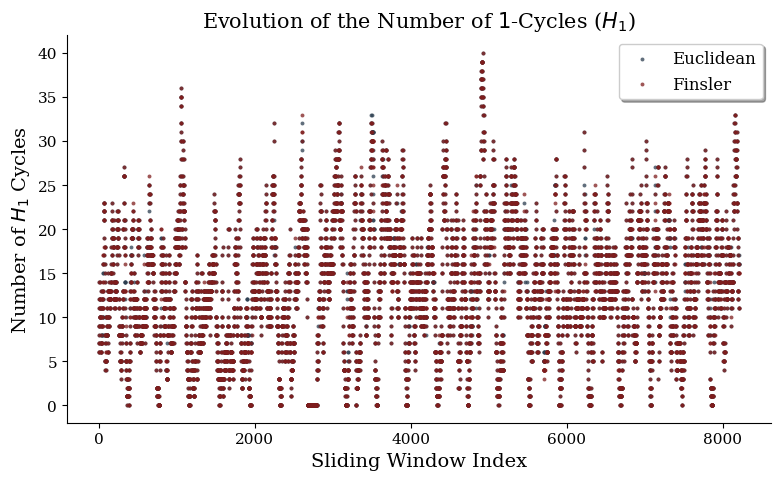

In [178]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Publication-like style
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, ax = plt.subplots(figsize=(8, 5))

# More professional colors
ax.scatter(
    range(len(H1_euclidean)),
    H1_euclidean,
    s=8,
    color="#2C3E50",   # dark blue-gray
    alpha=0.75,
    label="Euclidean",
    linewidths=0
)

ax.scatter(
    range(len(H1_finsler)),
    H1_finsler,
    s=8,
    color="#7F1D1D",   # deep burgundy
    alpha=0.75,
    label="Finsler",
    linewidths=0
)

# Labels and title
ax.set_xlabel("Sliding Window Index")
ax.set_ylabel(r"Number of $H_1$ Cycles")
ax.set_title(r"Evolution of the Number of $1$-Cycles ($H_1$)")

# Subtle grid
#ax.grid(True, linestyle="--", alpha=0.25)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Better legend
ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)

plt.tight_layout()
plt.show()

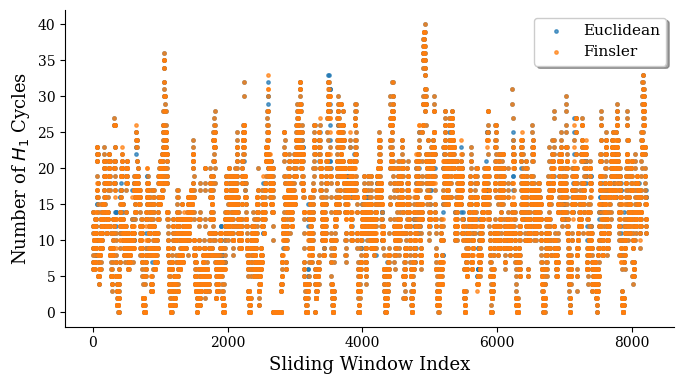

In [189]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))

ax.scatter(range(len(H1_euclidean)), H1_euclidean,
           s=6, alpha=0.7, label='Euclidean')

ax.scatter(range(len(H1_finsler)), H1_finsler,
           s=6, alpha=0.7, label='Finsler')

ax.set_xlabel("Sliding Window Index")
ax.set_ylabel(r"Number of $H_1$ Cycles")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)

plt.tight_layout()
plt.show()

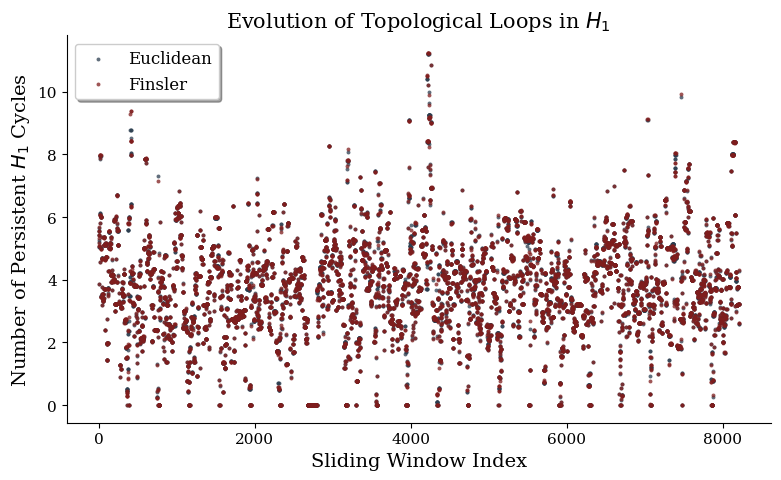

In [179]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Publication-like style
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, ax = plt.subplots(figsize=(8, 5))

# More professional colors
ax.scatter(
    range(len(percentages_max_H1_euclidean)),
    percentages_max_H1_euclidean,
    s=8,
    color="#2C3E50",   # dark blue-gray
    alpha=0.75,
    label="Euclidean",
    linewidths=0
)

ax.scatter(
    range(len(percentages_max_H1_finsler)),
    percentages_max_H1_finsler,
    s=8,
    color="#7F1D1D",   # deep burgundy
    alpha=0.75,
    label="Finsler",
    linewidths=0
)

# Labels and title
ax.set_xlabel("Sliding Window Index")
ax.set_ylabel(r"Number of Persistent $H_1$ Cycles")
ax.set_title(r"Evolution of Topological Loops in $H_1$")

# Subtle grid
#ax.grid(True, linestyle="--", alpha=0.25)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Better legend
ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)

plt.tight_layout()
plt.show()

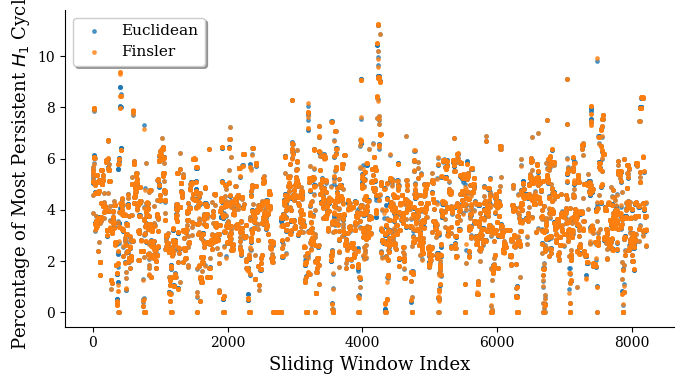

In [188]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))

ax.scatter(
    range(len(percentages_max_H1_euclidean)),
    percentages_max_H1_euclidean,
    s=6,
    alpha=0.7,
    label='Euclidean'
)

ax.scatter(
    range(len(percentages_max_H1_finsler)),
    percentages_max_H1_finsler,
    s=6,
    alpha=0.7,
    label='Finsler'
)

ax.set_xlabel("Sliding Window Index")
ax.set_ylabel(r"Percentage of Most Persistent $H_1$ Cycle")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

H1_entropy_finsler = []

for df in finsler_matrices:
    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True
    )['dgms']

    H1 = diagrams[1]

    if H1.size == 0:
        entropy = 0.0
    else:
        lifetimes = H1[:, 1] - H1[:, 0]

        total = np.sum(lifetimes)

        if total == 0:
            entropy = 0.0
        else:
            p = lifetimes / total

            entropy = -np.sum(
                p * np.log(p)
            )

    H1_entropy_finsler.append(entropy)

In [84]:
import numpy as np

H2_entropy_finsler = []

for df in finsler_matrices:
    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True,
        maxdim=2
    )['dgms']

    H2 = diagrams[2]

    if H2.size == 0:
        entropy = 0.0
    else:
        lifetimes = H2[:, 1] - H2[:, 0]

        total = np.sum(lifetimes)

        if total == 0:
            entropy = 0.0
        else:
            p = lifetimes / total

            entropy = -np.sum(
                p * np.log(p)
            )

    H2_entropy_finsler.append(entropy)

In [51]:
import numpy as np
from ripser import ripser

H1_entropy_finsler_normalized = []

for df in finsler_matrices:

    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True
    )['dgms']

    H1 = diagrams[1]

    # no H1 features
    if H1.size == 0:
        entropy = 0.0

    else:
        lifetimes = H1[:, 1] - H1[:, 0]

        # remove infinite or invalid values
        lifetimes = lifetimes[
            np.isfinite(lifetimes)
        ]

        total = np.sum(lifetimes)

        # degenerate case
        if total == 0 or len(lifetimes) <= 1:
            entropy = 0.0

        else:
            p = lifetimes / total

            # Shannon entropy
            H = -np.sum(
                p * np.log(p)
            )

            # normalize by log(n)
            entropy = (
                H /
                np.log(len(lifetimes))
            )

    H1_entropy_finsler_normalized.append(
        entropy
    )

In [88]:
import numpy as np
from ripser import ripser

H1_entropy_euclidean_normalized = []

for df in dist_matr_euclidean:

    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True
    )['dgms']

    H1 = diagrams[1]

    # no H1 features
    if H1.size == 0:
        entropy = 0.0

    else:
        lifetimes = H1[:, 1] - H1[:, 0]

        # remove infinite or invalid values
        lifetimes = lifetimes[
            np.isfinite(lifetimes)
        ]

        total = np.sum(lifetimes)

        # degenerate case
        if total == 0 or len(lifetimes) <= 1:
            entropy = 0.0

        else:
            p = lifetimes / total

            # Shannon entropy
            H = -np.sum(
                p * np.log(p)
            )

            # normalized entropy
            entropy = (
                H /
                np.log(len(lifetimes))
            )

    H1_entropy_euclidean_normalized.append(
        entropy
    )

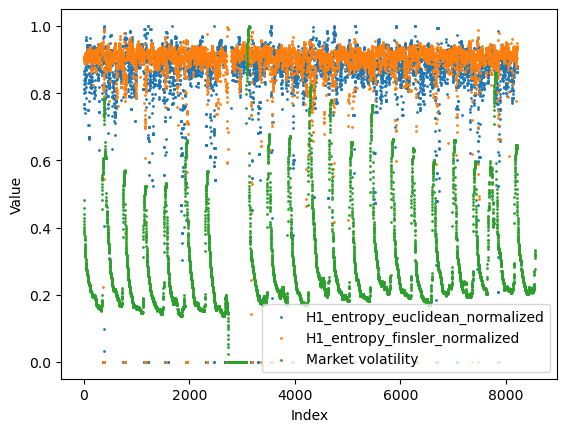

In [133]:
import matplotlib.pyplot as plt

plt.scatter(range(len(H1_entropy_euclidean_normalized)),
            H1_entropy_euclidean_normalized,
            s=1,
            label='H1_entropy_euclidean_normalized')

plt.scatter(range(len(H1_entropy_finsler_normalized)),
            H1_entropy_finsler_normalized,
            s=1,
            label='H1_entropy_finsler_normalized')

plt.scatter(range(len(market_volatility / market_volatility.max())),
            market_volatility / market_volatility.max(),
            s=1,
            label='Market volatility')

plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

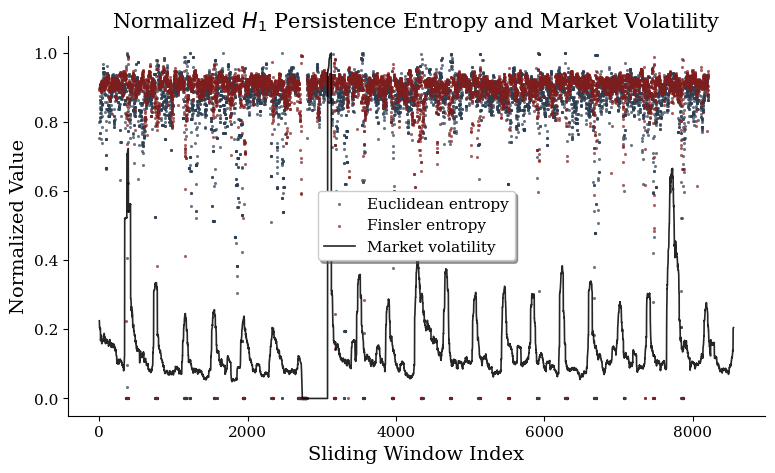

In [180]:
market_volatility_scaled = (
    market_volatility - market_volatility.min()
) / (
    market_volatility.max() - market_volatility.min()
)

# ----------------------------
# Publication-style formatting
# ----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, ax = plt.subplots(figsize=(9, 5))

# X-axis
x1 = np.arange(len(H1_entropy_euclidean_normalized))
x2 = np.arange(len(H1_entropy_finsler_normalized))
x3 = np.arange(len(market_volatility))

# ----------------------------
# Scatter plots for entropy
# ----------------------------
ax.scatter(
    x1,
    H1_entropy_euclidean_normalized,
    s=5,
    color="#2C3E50",      # dark blue-gray
    alpha=0.7,
    label="Euclidean entropy",
    linewidths=0
)

ax.scatter(
    x2,
    H1_entropy_finsler_normalized,
    s=5,
    color="#7F1D1D",      # burgundy
    alpha=0.7,
    label="Finsler entropy",
    linewidths=0
)

# ----------------------------
# Market volatility as line
# ----------------------------
ax.plot(
    x3,
    market_volatility_scaled,
    color="black",
    linewidth=1.2,
    alpha=0.85,
    label="Market volatility"
)

# ----------------------------
# Labels and title
# ----------------------------
ax.set_xlabel("Sliding Window Index")
ax.set_ylabel("Normalized Value")
ax.set_title(r"Normalized $H_1$ Persistence Entropy and Market Volatility")

# Subtle grid
#ax.grid(True, linestyle="--", alpha=0.25)

# Cleaner axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Minimal legend
ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)
plt.subplots_adjust(bottom=0.12)
plt.show()

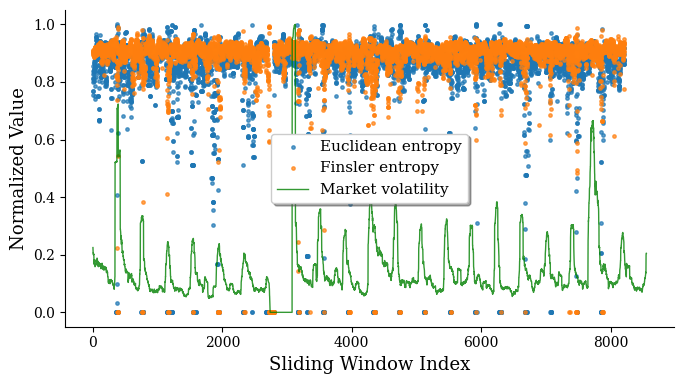

In [187]:
import matplotlib.pyplot as plt
import numpy as np

# Scale volatility
market_volatility_scaled = (
    market_volatility - market_volatility.min()
) / (
    market_volatility.max() - market_volatility.min()
)

fig, ax = plt.subplots(figsize=(7,4))

# X-axis
x1 = np.arange(len(H1_entropy_euclidean_normalized))
x2 = np.arange(len(H1_entropy_finsler_normalized))
x3 = np.arange(len(market_volatility_scaled))

# Scatter plots
ax.scatter(
    x1,
    H1_entropy_euclidean_normalized,
    s=6,
    alpha=0.7,
    label="Euclidean entropy"
)

ax.scatter(
    x2,
    H1_entropy_finsler_normalized,
    s=6,
    alpha=0.7,
    label="Finsler entropy"
)

# Market volatility in green
ax.plot(
    x3,
    market_volatility_scaled,
    color="green",
    linewidth=1,
    alpha=0.8,
    label="Market volatility"
)

# Labels
ax.set_xlabel("Sliding Window Index")
ax.set_ylabel("Normalized Value")

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend with subtle shadow
ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)

plt.tight_layout()
plt.show()

In [135]:
market_return = log_returns_df.mean(axis=1)

market_volatility = []

for i in range(len(market_return) - window_size + 1):

    window = market_return.iloc[i:i+window_size]

    market_volatility.append(window.std())

market_volatility = np.array(market_volatility)

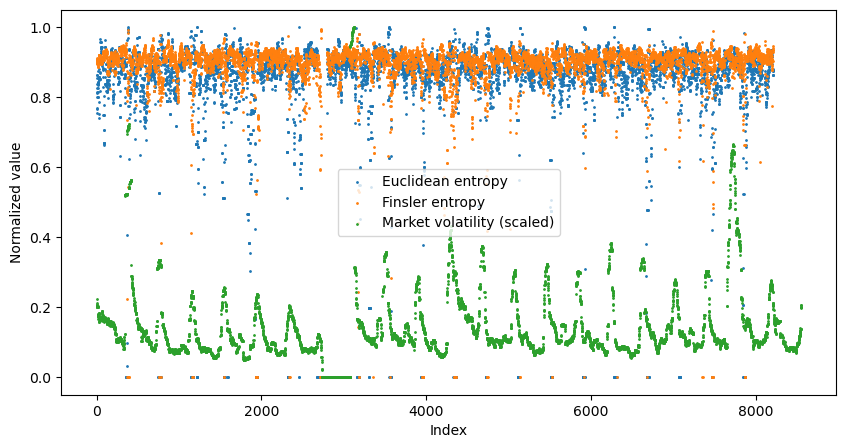

In [138]:
market_volatility_scaled = (
    market_volatility - market_volatility.min()
) / (
    market_volatility.max() - market_volatility.min()
)

plt.figure(figsize=(10,5))

plt.scatter(
    range(len(H1_entropy_euclidean_normalized)),
    H1_entropy_euclidean_normalized,
    s=1,
    label='Euclidean entropy'
)

plt.scatter(
    range(len(H1_entropy_finsler_normalized)),
    H1_entropy_finsler_normalized,
    s=1,
    label='Finsler entropy'
)

plt.scatter(
    range(len(market_volatility_scaled)),
    market_volatility_scaled,
    s=1,
    label='Market volatility (scaled)'
)

plt.xlabel('Index')
plt.ylabel('Normalized value')
plt.legend()
plt.show()

In [128]:
import numpy as np
from scipy.stats import skew, kurtosis

for name, x in [
    ('Euclidean', H1_entropy_euclidean_normalized),
    ('Finsler', H1_entropy_finsler_normalized)
]:
    print(name)
    print('mean:', np.mean(x))
    print('std:', np.std(x))
    print('skew:', skew(x))
    print('kurtosis:', kurtosis(x))
    print()

Euclidean
mean: 0.8221980523100437
std: 0.21233115489505297
skew: -3.272507930514163
kurtosis: 9.685493752336074

Finsler
mean: 0.8856952652141398
std: 0.12148164231010694
skew: -6.389370055848317
kurtosis: 42.91295765347274



In [170]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Compute statistics
stats = []

for name, x in [
    ('Euclidean', H1_entropy_euclidean_normalized),
    ('Finsler', H1_entropy_finsler_normalized)
]:
    stats.append({
        'Geometry': name,
        'Mean': np.mean(x),
        'Std. Dev.': np.std(x),
        'Skewness': skew(x),
        'Kurtosis': kurtosis(x)
    })

df_stats = pd.DataFrame(stats)

# Round values
df_stats = df_stats.round(4)

# Export to LaTeX
latex_table = df_stats.to_latex(
    index=False,
    caption='Statistical summary of normalized persistence entropy for $H_1$.',
    label='tab:H1_entropy_stats'
)

print(latex_table)

\begin{table}
\caption{Statistical summary of normalized persistence entropy for $H_1$.}
\label{tab:H1_entropy_stats}
\begin{tabular}{lrrrr}
\toprule
Geometry & Mean & Std. Dev. & Skewness & Kurtosis \\
\midrule
Euclidean & 0.822200 & 0.212300 & -3.272500 & 9.685500 \\
Finsler & 0.885700 & 0.121500 & -6.389400 & 42.913000 \\
\bottomrule
\end{tabular}
\end{table}



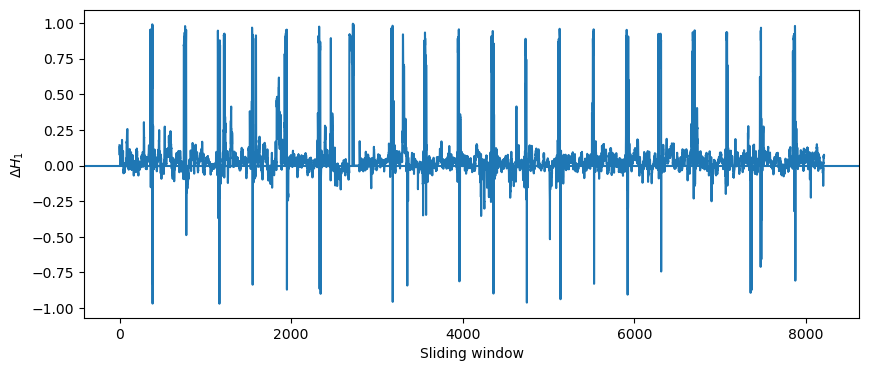

In [104]:
delta = (
    np.array(H1_entropy_finsler_normalized)
    - np.array(H1_entropy_euclidean_normalized)
)

plt.figure(figsize=(10,4))
plt.plot(delta)
plt.axhline(0)
plt.xlabel('Sliding window')
plt.ylabel(r'$\Delta H_1$')
plt.show()

In [87]:
import numpy as np
from ripser import ripser

H2_entropy_finsler_normalized = []

for df in finsler_matrices:

    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True, maxdim=2
    )['dgms']

    H2 = diagrams[2]

    # no H2 features
    if H2.size == 0:
        entropy = 0.0

    else:
        lifetimes = H2[:, 1] - H2[:, 0]

        # remove infinite/invalid values
        lifetimes = lifetimes[
            np.isfinite(lifetimes)
        ]

        total = np.sum(lifetimes)

        # degenerate case
        if total == 0 or len(lifetimes) <= 1:
            entropy = 0.0

        else:
            p = lifetimes / total

            # Shannon entropy
            H = -np.sum(
                p * np.log(p)
            )

            # normalized entropy
            entropy = (
                H /
                np.log(len(lifetimes))
            )

    H2_entropy_finsler_normalized.append(
        entropy
    )

In [90]:
import numpy as np
from ripser import ripser

H2_entropy_euclidean_normalized = []

for df in dist_matr_euclidean:

    D = df.values

    diagrams = ripser(
        D,
        distance_matrix=True,
        maxdim=2
    )['dgms']

    H2 = diagrams[2]

    # no H2 features
    if H2.size == 0:
        entropy = 0.0

    else:
        lifetimes = H2[:, 1] - H2[:, 0]

        lifetimes = lifetimes[
            np.isfinite(lifetimes)
        ]

        total = np.sum(lifetimes)

        if total == 0 or len(lifetimes) <= 1:
            entropy = 0.0

        else:
            p = lifetimes / total

            H = -np.sum(
                p * np.log(p)
            )

            entropy = (
                H /
                np.log(len(lifetimes))
            )

    H2_entropy_euclidean_normalized.append(
        entropy
    )

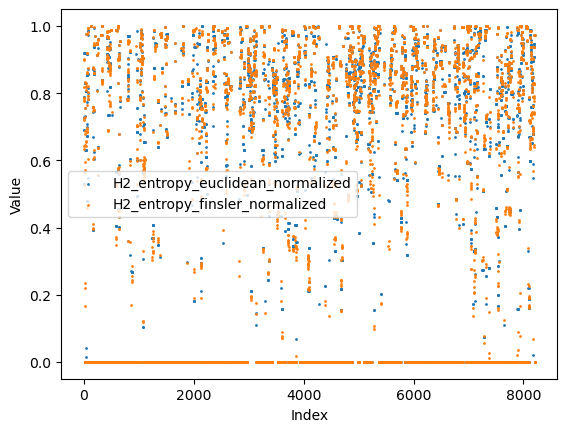

In [91]:
import matplotlib.pyplot as plt

plt.scatter(range(len(H2_entropy_euclidean_normalized)),
            H2_entropy_euclidean_normalized,
            s=1,
            label='H2_entropy_euclidean_normalized')

plt.scatter(range(len(H2_entropy_finsler_normalized)),
            H2_entropy_finsler_normalized,
            s=1,
            label='H2_entropy_finsler_normalized')

plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

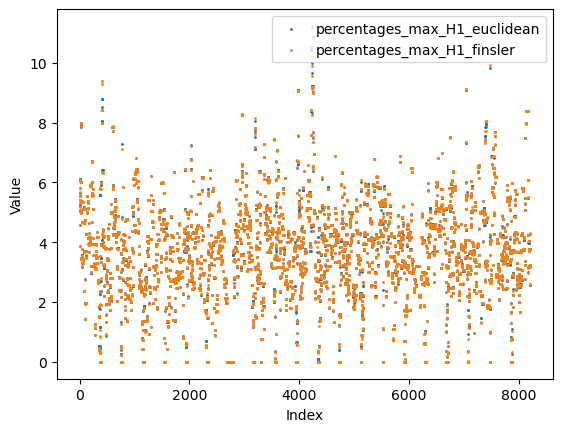

In [96]:
import matplotlib.pyplot as plt

plt.scatter(range(len(percentages_max_H1_euclidean)),
            percentages_max_H1_euclidean,
            s=1,
            label='percentages_max_H1_euclidean')

plt.scatter(range(len(percentages_max_H1_finsler)),
            percentages_max_H1_finsler,
            s=1,
            label='percentages_max_H1_finsler')

plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

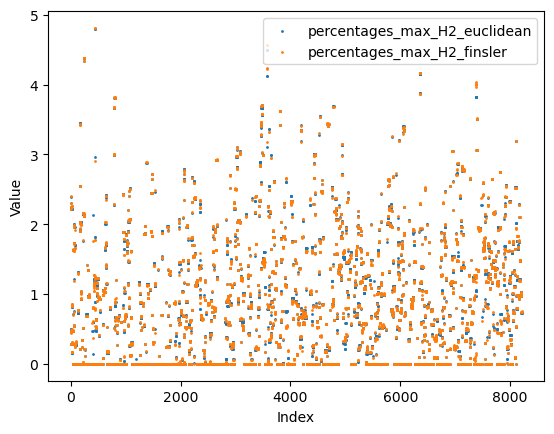

In [97]:
import matplotlib.pyplot as plt

plt.scatter(range(len(percentages_max_H2_euclidean)),
            percentages_max_H2_euclidean,
            s=1,
            label='percentages_max_H2_euclidean')

plt.scatter(range(len(percentages_max_H2_finsler)),
            percentages_max_H2_finsler,
            s=1,
            label='percentages_max_H2_finsler')

plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

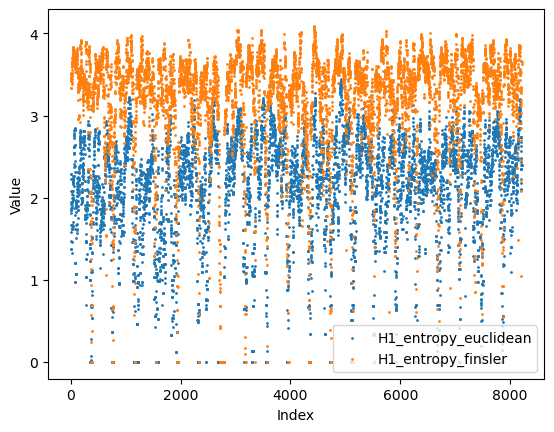

In [98]:
import matplotlib.pyplot as plt

plt.scatter(range(len(H1_entropy_euclidean)),
            H1_entropy_euclidean,
            s=1,
            label='H1_entropy_euclidean')

plt.scatter(range(len(H1_entropy_finsler)),
            H1_entropy_finsler,
            s=1,
            label='H1_entropy_finsler')

plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

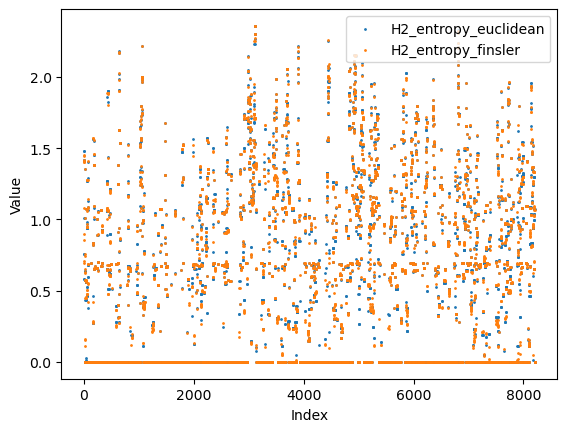

In [99]:
import matplotlib.pyplot as plt

plt.scatter(range(len(H2_entropy_euclidean)),
            H2_entropy_euclidean,
            s=1,
            label='H2_entropy_euclidean')

plt.scatter(range(len(H2_entropy_finsler)),
            H2_entropy_finsler,
            s=1,
            label='H2_entropy_finsler')

plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()

plt.show()

In [101]:
import numpy as np
from scipy.stats import skew, kurtosis

for name, x in [
    ('Euclidean', H1_entropy_euclidean),
    ('Finsler', H1_entropy_finsler)
]:
    print(name)
    print('mean:', np.mean(x))
    print('std:', np.std(x))
    print('skew:', skew(x))
    print('kurtosis:', kurtosis(x))
    print()

Euclidean
mean: 2.065697259263305
std: 0.7520709321350506
skew: -1.2788006217604437
kurtosis: 1.2168693507631652

Finsler
mean: 3.1992449324404517
std: 0.6883903393300744
skew: -2.5224410954395506
kurtosis: 7.6604962523395415



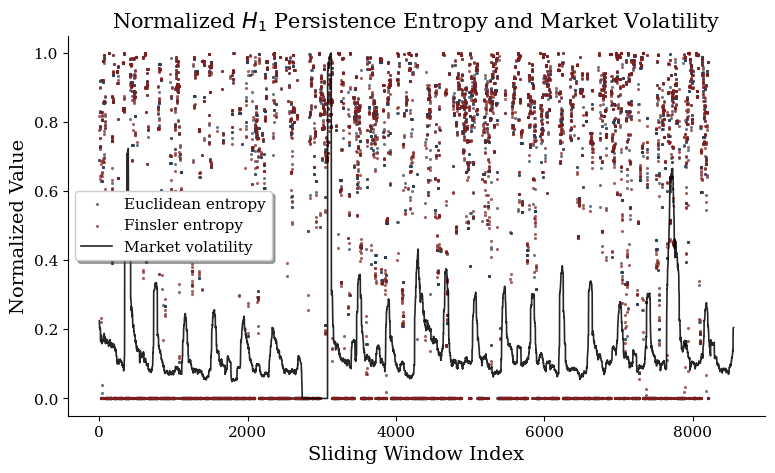

In [181]:
market_volatility_scaled = (
    market_volatility - market_volatility.min()
) / (
    market_volatility.max() - market_volatility.min()
)

# ----------------------------
# Publication-style formatting
# ----------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, ax = plt.subplots(figsize=(9, 5))

# X-axis
x1 = np.arange(len(H2_entropy_euclidean_normalized))
x2 = np.arange(len(H2_entropy_finsler_normalized))
x3 = np.arange(len(market_volatility))

# ----------------------------
# Scatter plots for entropy
# ----------------------------
ax.scatter(
    x1,
    H2_entropy_euclidean_normalized,
    s=5,
    color="#2C3E50",      # dark blue-gray
    alpha=0.7,
    label="Euclidean entropy",
    linewidths=0
)

ax.scatter(
    x2,
    H2_entropy_finsler_normalized,
    s=5,
    color="#7F1D1D",      # burgundy
    alpha=0.7,
    label="Finsler entropy",
    linewidths=0
)

# ----------------------------
# Market volatility as line
# ----------------------------
ax.plot(
    x3,
    market_volatility_scaled,
    color="black",
    linewidth=1.2,
    alpha=0.85,
    label="Market volatility"
)

# ----------------------------
# Labels and title
# ----------------------------
ax.set_xlabel("Sliding Window Index")
ax.set_ylabel("Normalized Value")
ax.set_title(r"Normalized $H_1$ Persistence Entropy and Market Volatility")

# Subtle grid
#ax.grid(True, linestyle="--", alpha=0.25)

# Cleaner axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Minimal legend
ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)
plt.subplots_adjust(bottom=0.12)
plt.show()

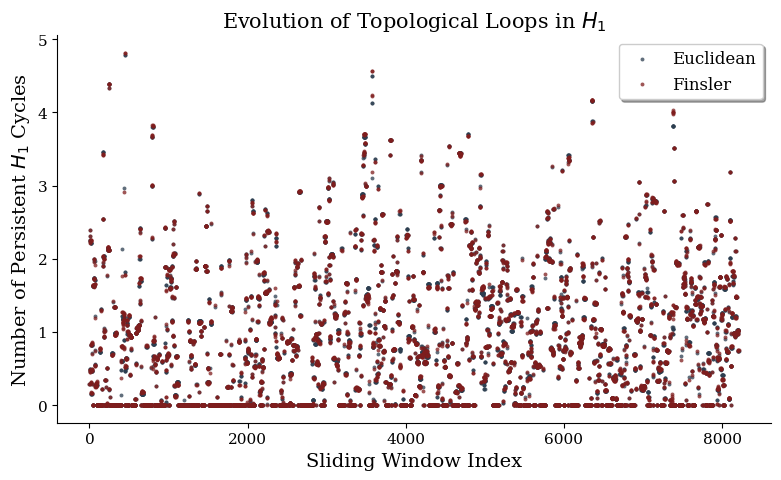

In [182]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Publication-like style
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, ax = plt.subplots(figsize=(8, 5))

# More professional colors
ax.scatter(
    range(len(percentages_max_H2_euclidean)),
    percentages_max_H2_euclidean,
    s=8,
    color="#2C3E50",   # dark blue-gray
    alpha=0.75,
    label="Euclidean",
    linewidths=0
)

ax.scatter(
    range(len(percentages_max_H2_finsler)),
    percentages_max_H2_finsler,
    s=8,
    color="#7F1D1D",   # deep burgundy
    alpha=0.75,
    label="Finsler",
    linewidths=0
)

# Labels and title
ax.set_xlabel("Sliding Window Index")
ax.set_ylabel(r"Number of Persistent $H_1$ Cycles")
ax.set_title(r"Evolution of Topological Loops in $H_1$")

# Subtle grid
#ax.grid(True, linestyle="--", alpha=0.25)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Better legend
ax.legend(
    frameon=True,
    shadow=True,
    fancybox=True
)

plt.tight_layout()
plt.show()